<a href="https://colab.research.google.com/github/KaabiHiba/FER-CE-Project/blob/main/Hiba_Moncef_version0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
BASE_PATH = "/content/drive/MyDrive/compound"
IMAGE_PATH = os.path.join(BASE_PATH, "Image/aligned")
LABEL_PATH = os.path.join(BASE_PATH, "EmoLabel/list_patition_label.txt")

labels_dict = {}

with open(LABEL_PATH, "r") as f:
    for line in f:
        name, label = line.strip().split()
        labels_dict[name] = int(label) - 1  # 🔥 start from 0

In [4]:
train_images = []
test_images = []

for name in labels_dict.keys():
    if "train" in name:
        train_images.append(name)
    else:
        test_images.append(name)

print(len(train_images), len(test_images))

3162 792


In [5]:
class EmotionDataset(Dataset):
    def __init__(self, image_list, transform=None):
        self.image_list = image_list
        self.transform = transform

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        img_name = self.image_list[idx]
        real_name = img_name.replace(".jpg", "_aligned.jpg")
        img_path = os.path.join(IMAGE_PATH, real_name)

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            # Return black image + correct label to avoid crashing
            image = Image.new("RGB", (224, 224), (0, 0, 0))

        if self.transform:
            image = self.transform(image)

        label = labels_dict[img_name]
        return image, label

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3,0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [7]:
train_data, val_data = train_test_split(train_images, test_size=0.2, random_state=42)

train_dataset = EmotionDataset(train_data, transform=train_transform)
val_dataset = EmotionDataset(val_data, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, drop_last=True, num_workers=2)

In [8]:
labels_array = [labels_dict[x] for x in train_data]

num_classes = 14
class_weights = np.ones(num_classes)

unique_classes = np.unique(labels_array)

computed_weights = compute_class_weight(
    class_weight="balanced",
    classes=unique_classes,
    y=labels_array
)

for i, c in enumerate(unique_classes):
    class_weights[c] = computed_weights[i]

weights = torch.tensor(class_weights, dtype=torch.float)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

Device utilisé : cpu


In [10]:
model = models.resnet18(weights="DEFAULT")

for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.6),
    nn.Linear(512, 14)
)

model = model.to(device)

In [11]:
weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [12]:
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

In [13]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    patience=2,
    factor=0.3
)

In [14]:
num_epochs = 25
best_acc = 0

for epoch in range(num_epochs):
    print(f"\n🚀 Epoch {epoch+1}/{num_epochs}")

    model.train()
    running_loss = 0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if i % 20 == 0:
            print(f"Batch {i}/{len(train_loader)} - Loss: {loss.item():.4f}")

    # VALIDATION
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    acc = 100 * correct / total
    epoch_loss = running_loss / len(train_loader)

    print(f"✅ Epoch {epoch+1} | Loss: {epoch_loss:.4f} | Acc: {acc:.2f}%")

    scheduler.step(acc)

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "/content/drive/MyDrive/best_model.pth")
        print("🔥 Best model saved!")


🚀 Epoch 1/25
Batch 0/79 - Loss: 2.7596
Batch 20/79 - Loss: 2.6361
Batch 40/79 - Loss: 2.6087
Batch 60/79 - Loss: 2.5533
✅ Epoch 1 | Loss: 2.5049 | Acc: 18.59%
🔥 Best model saved!

🚀 Epoch 2/25
Batch 0/79 - Loss: 2.2562
Batch 20/79 - Loss: 2.2463
Batch 40/79 - Loss: 2.2668
Batch 60/79 - Loss: 2.2406
✅ Epoch 2 | Loss: 2.1523 | Acc: 25.99%
🔥 Best model saved!

🚀 Epoch 3/25
Batch 0/79 - Loss: 2.0373
Batch 20/79 - Loss: 2.0541
Batch 40/79 - Loss: 1.9208
Batch 60/79 - Loss: 2.1008
✅ Epoch 3 | Loss: 1.9799 | Acc: 23.19%

🚀 Epoch 4/25
Batch 0/79 - Loss: 1.3513
Batch 20/79 - Loss: 1.8235
Batch 40/79 - Loss: 1.9369
Batch 60/79 - Loss: 1.8550
✅ Epoch 4 | Loss: 1.8126 | Acc: 29.61%
🔥 Best model saved!

🚀 Epoch 5/25
Batch 0/79 - Loss: 1.6789
Batch 20/79 - Loss: 1.7373
Batch 40/79 - Loss: 1.6516
Batch 60/79 - Loss: 1.8703
✅ Epoch 5 | Loss: 1.6719 | Acc: 32.89%
🔥 Best model saved!

🚀 Epoch 6/25
Batch 0/79 - Loss: 1.8033
Batch 20/79 - Loss: 1.2948
Batch 40/79 - Loss: 1.8699
Batch 60/79 - Loss: 1.5981

In [15]:
class_names = [
    "Neutral", "Happy", "Sad", "Surprise",
    "Fear", "Disgust", "Angry", "Contempt",
    "Happily Surprised", "Sadly Angry",
    "Sadly Surprised", "Fearfully Surprised",
    "Angrily Surprised", "Disgustedly Surprised"
]

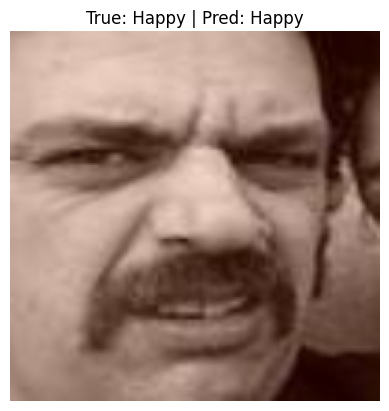

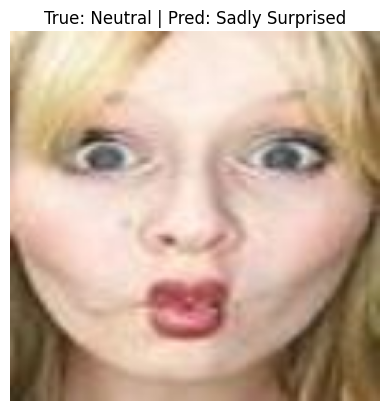

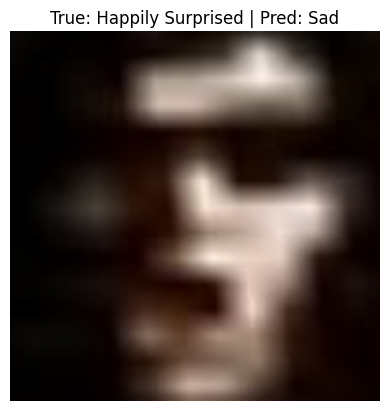

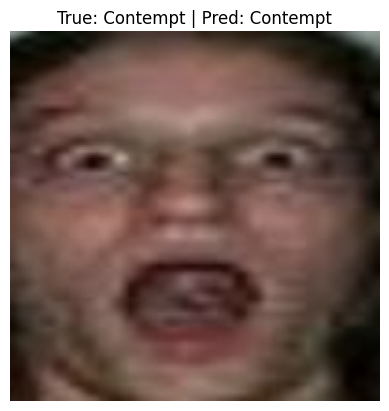

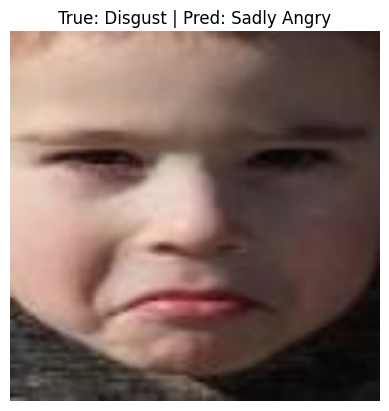

In [16]:
model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pth"))
model.eval()

import matplotlib.pyplot as plt
import random

for i in range(5):
    img, label = val_dataset[random.randint(0, len(val_dataset)-1)]

    input_img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_img)
        _, pred = torch.max(output, 1)

    img_show = img.permute(1,2,0).cpu().numpy()
    img_show = (img_show * 0.5) + 0.5

    plt.imshow(img_show)
    plt.title(f"True: {class_names[label]} | Pred: {class_names[pred.item()]}")
    plt.axis("off")
    plt.show()

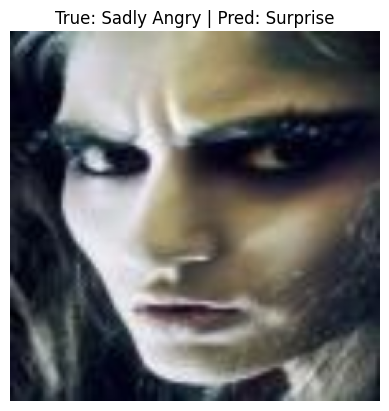

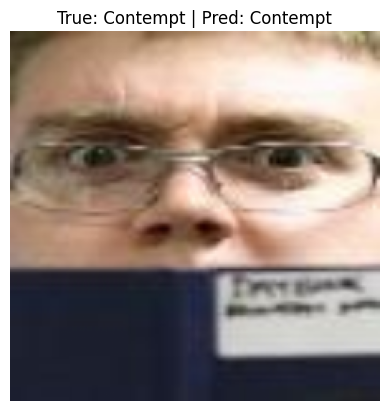

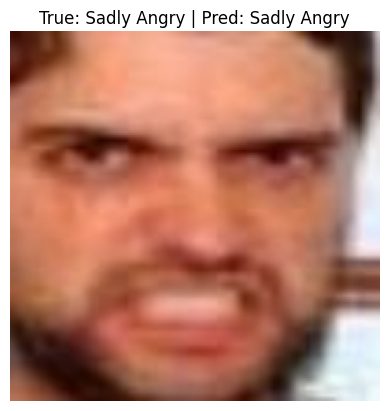

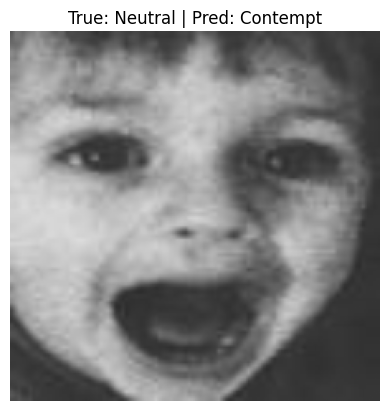

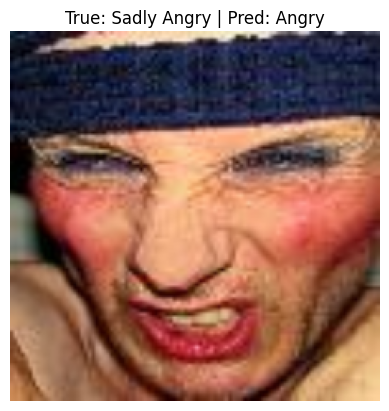

In [17]:
model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pth"))
model.eval()

import matplotlib.pyplot as plt
import random

for i in range(5):
    img, label = val_dataset[random.randint(0, len(val_dataset)-1)]

    input_img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_img)
        _, pred = torch.max(output, 1)

    img_show = img.permute(1,2,0).cpu().numpy()
    img_show = (img_show * 0.5) + 0.5

    plt.imshow(img_show)
    plt.title(f"True: {class_names[label]} | Pred: {class_names[pred.item()]}")
    plt.axis("off")
    plt.show()

              precision    recall  f1-score   support

           0       0.61      0.44      0.51       100
           1       0.36      0.41      0.38        49
           2       0.22      0.35      0.27        23
           3       0.28      0.38      0.32        21
           4       0.09      0.12      0.10        17
           5       0.58      0.48      0.53       118
           6       0.46      0.63      0.53        19
           7       0.47      0.68      0.56        76
           8       0.36      0.17      0.23        29
           9       0.56      0.46      0.50       127
          10       0.15      0.21      0.17        29

    accuracy                           0.45       608
   macro avg       0.38      0.39      0.37       608
weighted avg       0.48      0.45      0.45       608



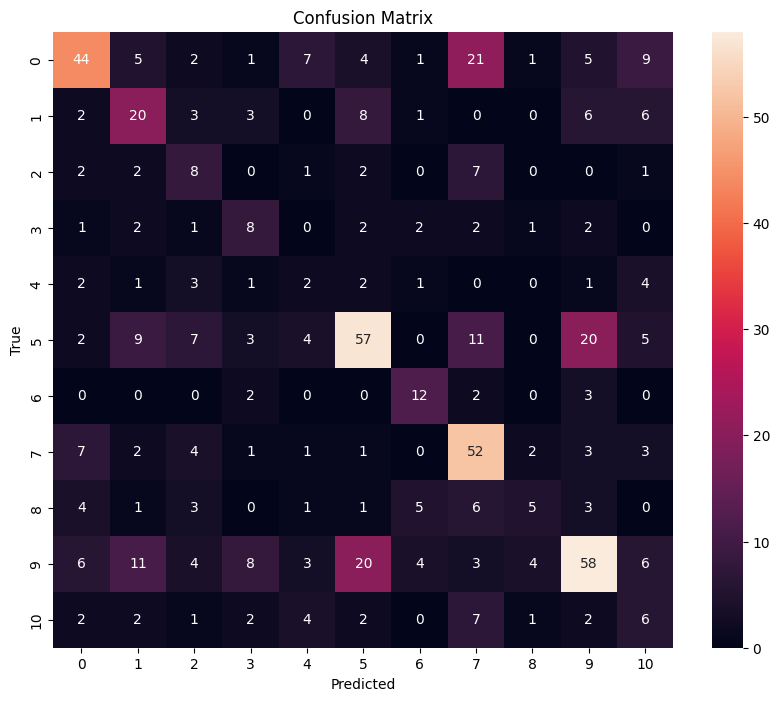

In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Report
print(classification_report(y_true, y_pred))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [19]:
!pip install transformers accelerate

In [20]:
from transformers import BlipProcessor, BlipForConditionalGeneration
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

print("✅ BLIP model loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

✅ BLIP model loaded


In [21]:
from PIL import Image

def generate_caption(image_path):
    image = Image.open(image_path).convert("RGB")

    prompt = "Describe the facial emotion and explain the facial features (eyes, mouth, eyebrows)."

    inputs = processor(image, text=prompt, return_tensors="pt").to(device)

    out = blip_model.generate(**inputs, max_new_tokens=50)

    caption = processor.decode(out[0], skip_special_tokens=True)

    return caption

In [22]:
emotion_explanations = {
    "happily surprised": "smiling mouth and raised eyebrows",
    "sadly angry": "frowning eyebrows and tense lips",
    "fearfully disgusted": "wide eyes and wrinkled nose",
    "happily disgusted": "smile with slight nose wrinkle",
    "sadly fearful": "drooping eyes and slightly open mouth",
    "angrily surprised": "wide eyes with tense eyebrows",
    "sadly surprised": "raised eyebrows with sad mouth",
    "disgustedly surprised": "wrinkled nose and raised eyebrows",
    "fearfully surprised": "wide eyes and open mouth",
    "angrily disgusted": "tight lips and wrinkled nose",
    "sadly disgusted": "downturned lips and nose wrinkle",
    "happily angry": "smile with tense eyebrows",
    "fearfully angry": "wide eyes with tight lips",
    "neutral": "relaxed face with no strong emotion"
}

In [23]:
import matplotlib.pyplot as plt

def predict_with_explanation(img_path):

    image = Image.open(img_path).convert("RGB")

    plt.imshow(image)
    plt.title("Image")
    plt.axis("off")
    plt.show()

    img = val_transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img)
        _, pred = torch.max(output, 1)

    emotion = emotion_labels[pred.item()]
    explanation = emotion_explanations[emotion]

    print("😊 Emotion prédite :", emotion)
    print("🧠 Explication :", explanation)

In [24]:
emotion_labels = [
    "happily surprised", "sadly angry", "fearfully disgusted",
    "happily disgusted", "sadly fearful", "angrily surprised",
    "sadly surprised", "disgustedly surprised",
    "fearfully surprised", "angrily disgusted",
    "sadly disgusted", "happily angry",
    "fearfully angry", "neutral"
]

import matplotlib.pyplot as plt

def predict_with_explanation(img_path):

    # 🔹 afficher image
    image = Image.open(img_path).convert("RGB")
    plt.imshow(image)
    plt.title("Image test")
    plt.axis("off")
    plt.show()

    # 🔹 CNN
    img = val_transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img)
        _, pred = torch.max(output, 1)

    emotion = emotion_labels[pred.item()]

    # 🔹 LLM
    caption = generate_caption(img_path)

    print("😊 Emotion prédite :", emotion)
    print("🧠 Explication :", caption)

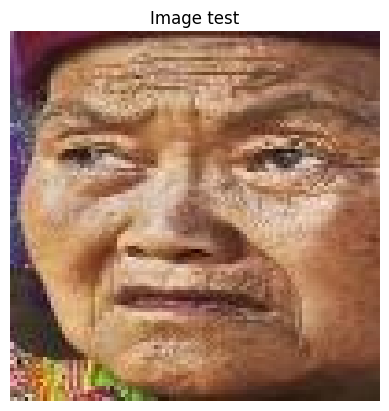

😊 Emotion prédite : happily surprised
🧠 Explication : describe the facial emotion and explain the facial features ( eyes, mouth, eyebrows )., chino, chino, chino, chin


In [25]:
test_img = "/content/drive/MyDrive/compound/Image/aligned/train_0001_aligned.jpg"

predict_with_explanation(test_img)

In [26]:
!pip install open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.7 MB/s eta 0:00:00


In [27]:
import torch
import open_clip
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_clip, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32', pretrained='openai'
)
model_clip = model_clip.to(device)

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


In [28]:
text_prompts = [
    "a person smiling with raised eyebrows",
    "a person with angry eyebrows and sad mouth",
    "a person with wide eyes and disgusted face",
    "a smiling person with slight disgust",
    "a sad person with fearful eyes",
    "an angry person with surprised expression",
    "a sad person with raised eyebrows",
    "a disgusted person with surprised face",
    "a person with wide eyes and open mouth",
    "an angry person with disgust expression",
    "a sad person with disgust expression",
    "a smiling person with anger",
    "a fearful person with anger",
    "a neutral face"
]

In [29]:
import matplotlib.pyplot as plt
from PIL import Image

# ✅ dictionnaire d'explications
emotion_explanations = {
    "a person smiling with raised eyebrows": "Positive emotion with engagement (joy + surprise)",
    "a person with angry eyebrows and sad mouth": "Mixed negative emotion (anger + sadness)",
    "a person with wide eyes and disgusted face": "Disgust combined with surprise",
    "a smiling person with slight disgust": "Conflicting signals (joy + disgust)",
    "a sad person with fearful eyes": "Fear mixed with sadness",
    "an angry person with surprised expression": "High arousal emotion (anger + surprise)",
    "a sad person with raised eyebrows": "Sadness with concern or worry",
    "a disgusted person with surprised face": "Disgust mixed with surprise",
    "a person with wide eyes and open mouth": "Strong surprise or fear",
    "an angry person with disgust expression": "Intense negative emotion (anger + disgust)",
    "a sad person with disgust expression": "Negative emotional blend",
    "a smiling person with anger": "Mixed emotion (joy + anger)",
    "a fearful person with anger": "Fear combined with aggression",
    "a neutral face": "No strong emotion detected"
}

def predict_clip_full(image_path):

    # 🔹 afficher image
    image = Image.open(image_path).convert("RGB")
    plt.imshow(image)
    plt.title("Image test")
    plt.axis("off")
    plt.show()

    # 🔹 preprocess
    image_input = preprocess(image).unsqueeze(0).to(device)
    text = open_clip.tokenize(text_prompts).to(device)

    with torch.no_grad():
        image_features = model_clip.encode_image(image_input)
        text_features = model_clip.encode_text(text)

        # 🔥 normalisation (très important)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)

        logits = image_features @ text_features.T
        probs = logits.softmax(dim=-1)

    pred = probs.argmax().item()

    # 🔹 émotion détectée
    emotion = text_prompts[pred]

    # 🔹 explication
    explanation = emotion_explanations.get(
        emotion,
        "Facial expression detected but not clearly classified"
    )

    # 🔹 affichage
    print("😊 Emotion (CLIP) :", emotion)
    print("🧠 Explication :", explanation)
    print("📊 Probabilités :", probs.cpu().numpy())

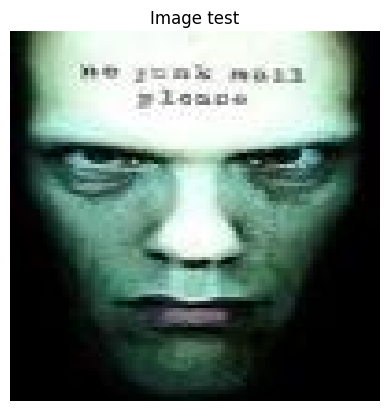

😊 Emotion (CLIP) : a fearful person with anger
🧠 Explication : Fear combined with aggression
📊 Probabilités : [[0.07048687 0.0716954  0.06992467 0.07095791 0.07181186 0.07115905
  0.07148643 0.0700992  0.07057943 0.07299207 0.07209732 0.07167634
  0.0732677  0.07176574]]


In [30]:
img_path = "/content/drive/MyDrive/compound/Image/aligned/train_0005_aligned.jpg"
predict_clip_full(img_path)

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [32]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image, class_idx):
        self.model.zero_grad()

        output = self.model(input_image)
        loss = output[0, class_idx]
        loss.backward()

        gradients = self.gradients[0].cpu().data.numpy()
        activations = self.activations[0].cpu().data.numpy()

        weights = np.mean(gradients, axis=(1, 2))

        cam = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224, 224))
        cam = cam - cam.min()
        cam = cam / cam.max()

        return cam

In [33]:
target_layer = model.layer4
gradcam = GradCAM(model, target_layer)

In [34]:
def show_gradcam(img_path):
    model.eval()

    img = Image.open(img_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    input_tensor = transform(img).unsqueeze(0).to(device)

    # prediction
    output = model(input_tensor)
    _, pred = torch.max(output, 1)

    # Grad-CAM
    cam = gradcam.generate(input_tensor, pred.item())

    # image originale
    img_np = np.array(img.resize((224,224)))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255

    superimposed = heatmap + np.float32(img_np)/255
    superimposed = superimposed / np.max(superimposed)

    # affichage
    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(img_np)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(cam, cmap='jet')
    plt.title("Heatmap")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(superimposed)
    plt.title(f"Pred: {pred.item()}")
    plt.axis('off')

    plt.show()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


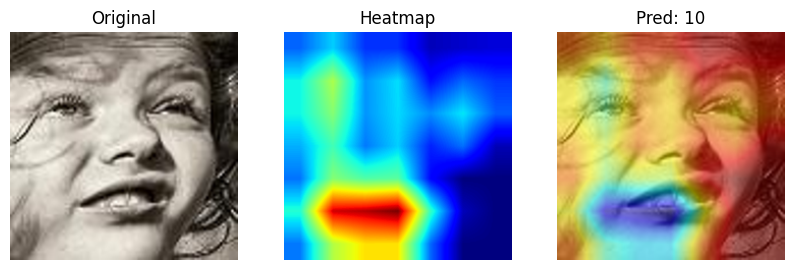

In [35]:
img_path = "/content/drive/MyDrive/compound/Image/aligned/train_0009_aligned.jpg"

show_gradcam(img_path)

In [36]:
def compare_predictions(img_path):
    model.eval()

    img = Image.open(img_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    input_tensor = transform(img).unsqueeze(0).to(device)

    # prediction
    output = model(input_tensor)
    _, pred = torch.max(output, 1)

    print("Prediction ResNet:", pred.item())

    # Grad-CAM
    cam = gradcam.generate(input_tensor, pred.item())

    plt.imshow(cam, cmap='jet')
    plt.title("Zones importantes (Grad-CAM)")
    plt.axis('off')
    plt.show()

Prediction ResNet: 10


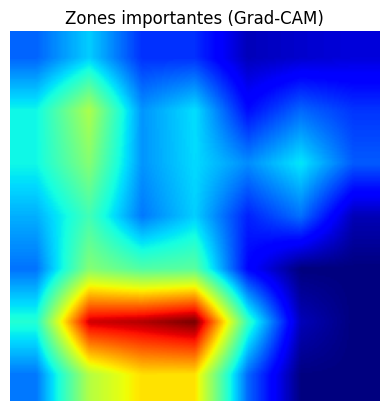

In [37]:
compare_predictions("/content/drive/MyDrive/compound/Image/aligned/train_0009_aligned.jpg")

In [38]:
def analyze_attention(cam):
    h, w = cam.shape

    top = cam[:h//3, :]
    middle = cam[h//3:2*h//3, :]
    bottom = cam[2*h//3:, :]

    top_score = np.mean(top)
    mid_score = np.mean(middle)
    bot_score = np.mean(bottom)

    if top_score > mid_score and top_score > bot_score:
        return "eyes"
    elif bot_score > mid_score and bot_score > top_score:
        return "mouth"
    else:
        return "center_face"

In [39]:
def generate_explanation(pred_class, focus_area):

    emotions = [
        "Neutral", "Happy", "Sad", "Surprise", "Fear",
        "Disgust", "Anger", "Contempt", "Anxiety",
        "Helplessness", "Disappointment", "Boredom",
        "Calm", "Confusion"
    ]

    emotion = emotions[pred_class]

    if focus_area == "eyes":
        focus_text = "the eyes"
    elif focus_area == "mouth":
        focus_text = "the mouth"
    else:
        focus_text = "the central facial region"

    explanation = f"The model predicts '{emotion}' because it focuses mainly on {focus_text}."

    return explanation

In [40]:
def show_gradcam_with_text(img_path):
    model.eval()

    img = Image.open(img_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    input_tensor = transform(img).unsqueeze(0).to(device)

    # prediction
    output = model(input_tensor)
    pred_class = output.argmax(dim=1).item()

    # Grad-CAM
    cam = gradcam.generate(input_tensor, pred_class)

    # 🔥 analyse zones
    focus_area = analyze_attention(cam)

    # 🔥 génération texte
    explanation = generate_explanation(pred_class, focus_area)

    # image originale
    img_np = np.array(img.resize((224,224)))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255

    superimposed = heatmap + np.float32(img_np)/255
    superimposed = superimposed / np.max(superimposed)

    # affichage
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img_np)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(cam, cmap='jet')
    plt.title("Heatmap")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(superimposed)
    plt.title(f"Pred: {pred_class}")
    plt.axis('off')

    plt.show()

    # 🔥 texte final
    print("🧠 Explanation:")
    print(explanation)

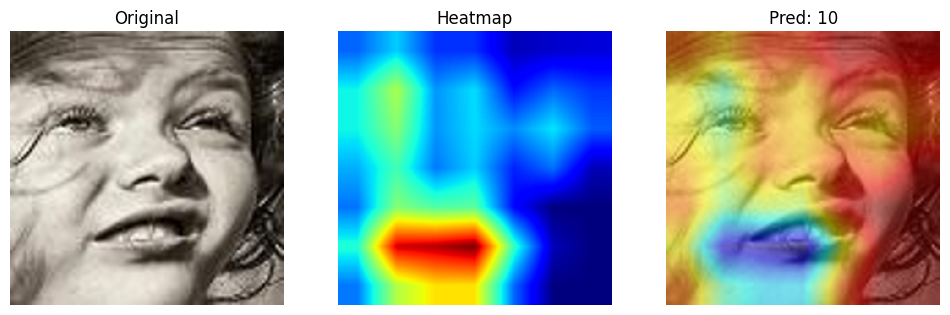

🧠 Explanation:
The model predicts 'Disappointment' because it focuses mainly on the mouth.


In [41]:
show_gradcam_with_text(img_path)

In [42]:
def full_test(img_path):
    model.eval()

    # preprocess
    img = Image.open(img_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    input_tensor = transform(img).unsqueeze(0).to(device)

    # prediction
    output = model(input_tensor)
    probs = torch.softmax(output, dim=1)
    top3_prob, top3_class = torch.topk(probs, 3)

    pred_class = top3_class[0][0].item()

    print("Top 3 classes:", top3_class)
    print("Probabilities:", top3_prob)

    # Grad-CAM
    cam = gradcam.generate(input_tensor, pred_class)

    # affichage
    img_np = np.array(img.resize((224,224)))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255

    superimposed = heatmap + np.float32(img_np)/255
    superimposed = superimposed / np.max(superimposed)

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(img_np)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(cam, cmap='jet')
    plt.title("Grad-CAM")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(superimposed)
    plt.title(f"Pred: {pred_class}")
    plt.axis('off')

    plt.show()

    return pred_class

IMAGE 1
Top 3 classes: tensor([[0, 7, 8]])
Probabilities: tensor([[0.3038, 0.2274, 0.1340]], grad_fn=<TopkBackward0>)


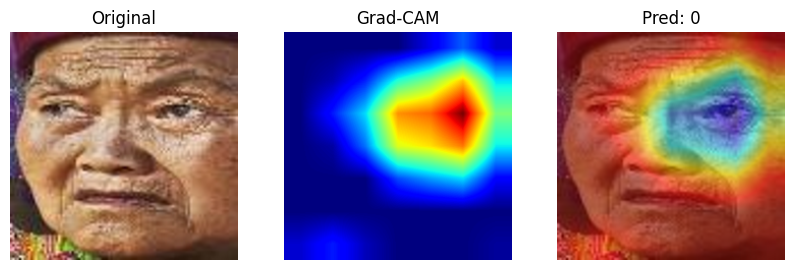

IMAGE 2
Top 3 classes: tensor([[1, 5, 9]])
Probabilities: tensor([[0.3187, 0.2024, 0.1926]], grad_fn=<TopkBackward0>)


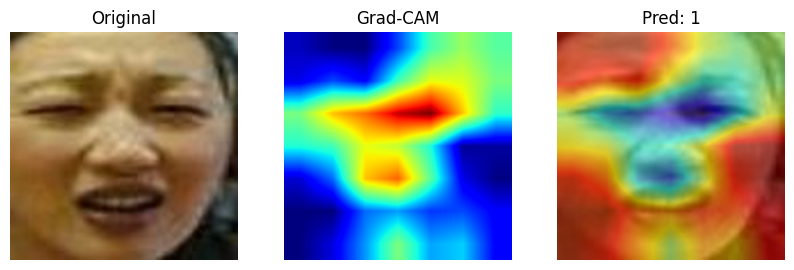

IMAGE 3
Top 3 classes: tensor([[9, 3, 4]])
Probabilities: tensor([[0.6028, 0.0883, 0.0691]], grad_fn=<TopkBackward0>)


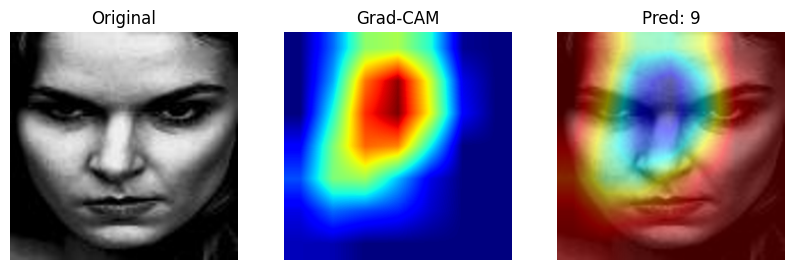

IMAGE 4
Top 3 classes: tensor([[3, 2, 9]])
Probabilities: tensor([[0.9218, 0.0211, 0.0158]], grad_fn=<TopkBackward0>)


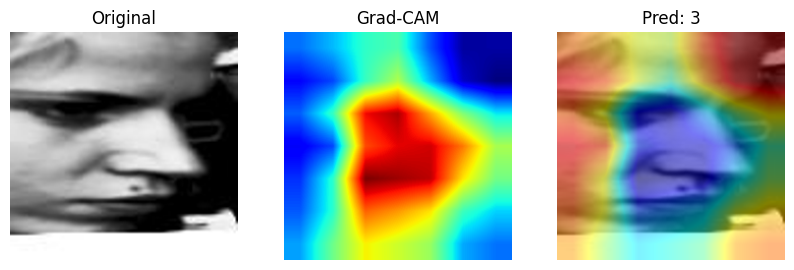

IMAGE 5
Top 3 classes: tensor([[9, 6, 2]])
Probabilities: tensor([[0.6548, 0.2145, 0.0410]], grad_fn=<TopkBackward0>)


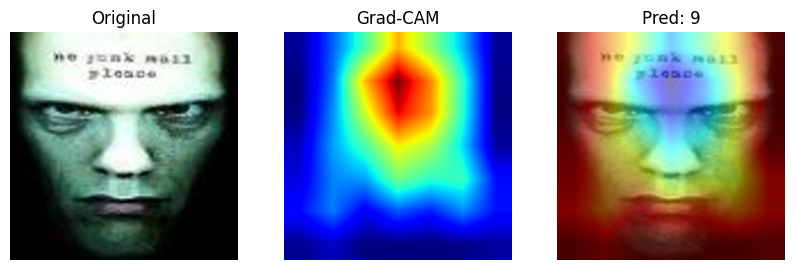

In [43]:
for i in range(1, 6):
    path = f"/content/drive/MyDrive/compound/Image/aligned/train_000{i}_aligned.jpg"
    print("IMAGE", i)
    full_test(path)

In [44]:
def explain_prediction(pred_class):
    emotions = [
        "Happiness", "Sadness", "Surprise", "Fear",
        "Anger", "Disgust", "Contempt", "Neutral",
        "Anxiety", "Helplessness", "Disappointment",
        "Pride", "Shame", "Interest"
    ]

    return f"The model predicts '{emotions[pred_class]}' because it focuses on key facial regions like eyes and mouth."

Top 3 classes: tensor([[10,  9,  5]])
Probabilities: tensor([[0.3200, 0.2086, 0.1440]], grad_fn=<TopkBackward0>)


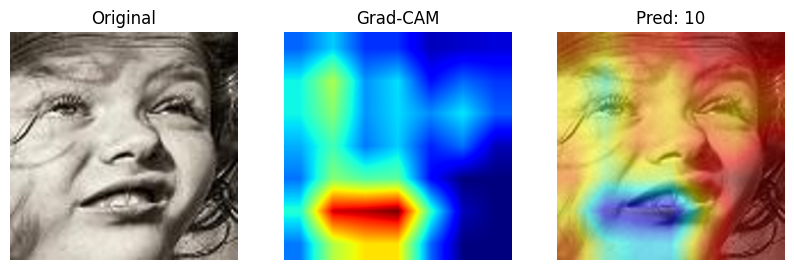

The model predicts 'Disappointment' because it focuses on key facial regions like eyes and mouth.


In [45]:
img_path_to_explain = '/content/drive/MyDrive/compound/Image/aligned/train_0009_aligned.jpg'
pred_class_for_explanation = full_test(img_path_to_explain)
print(explain_prediction(pred_class_for_explanation))

In [46]:
!pip install gradio

In [47]:
from PIL import Image
import torch
import numpy as np

def predict_image(img_path):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((224,224))

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    img = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img)
        _, pred = torch.max(output, 1)

    return pred.item()

In [48]:
img_path = "/content/drive/MyDrive/compound/Image/aligned/train_0001_aligned.jpg"
print("Prediction:", predict_image(img_path))

Prediction: 0


In [49]:
import gradio as gr
from PIL import Image
import torch
from torchvision import transforms

# Labels (adapter selon ton dataset)
emotion_labels = [
    "Neutral", "Happy", "Sad", "Surprise", "Fear",
    "Disgust", "Anger", "Contempt", "Anxiety",
    "Helplessness", "Disappointment", "Other1", "Other2", "Other3"
]

def predict_and_explain(image):
    # Transform
    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    img = transform(image).unsqueeze(0).to(device)

    # Prediction
    model.eval()
    with torch.no_grad():
        output = model(img)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    # Texte explicatif (Vision-LLM simple)
    explanation = f"The model predicts '{emotion_labels[pred]}' because it focuses on key facial regions."

    return emotion_labels[pred], explanation

In [50]:
interface = gr.Interface(
    fn=predict_and_explain,
    inputs=gr.Image(type="pil"),
    outputs=["label", "text"],
    title="FER Emotion Recognition",
    description="Upload an image to detect emotion"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://80568bfd64397d4a63.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
